# Tarea 2: Bayes, MDS.
Nombre: Patricio Espinoza A

Curso: MDS7104 - Aprendizaje de Maquinas

## Pregunta 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# seed
random.seed(42)
np.random.seed(42)

# Load data
data = np.loadtxt("data_p2.txt")

x = data[:, 0]  # months
y = data[:, 1]  # passengers

In [3]:
# Total number of samples
n = len(x)

# Index to split the data (75% train, 25% test)
n_train = int(0.75 * n)

# Train (75%)
x_train, y_train = x[:n_train], y[:n_train]
# Test (25%)
x_test, y_test = x[n_train:], y[n_train:]

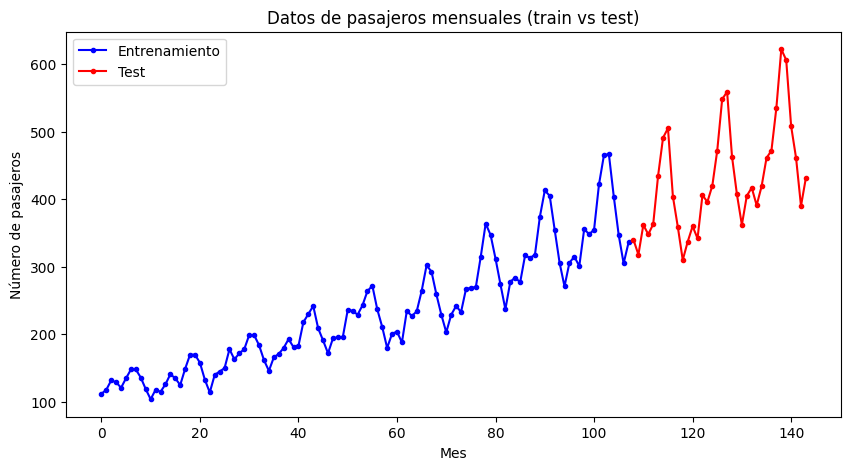

In [4]:
# (a) Plot train and test data
plt.figure(figsize=(10,5))
plt.plot(x_train, y_train, 'b.-', label="Entrenamiento")
plt.plot(x_test, y_test, 'r.-', label="Test")
plt.xlabel("Mes")
plt.ylabel("Número de pasajeros")
plt.title("Datos de pasajeros mensuales (train vs test)")
plt.legend()
plt.show()

In [5]:
# (b)
degrees = [1, 2, 3, 4, 5]
models = {}

for d in degrees:
    coefs = np.polyfit(x_train, y_train, d)
    models[d] = coefs

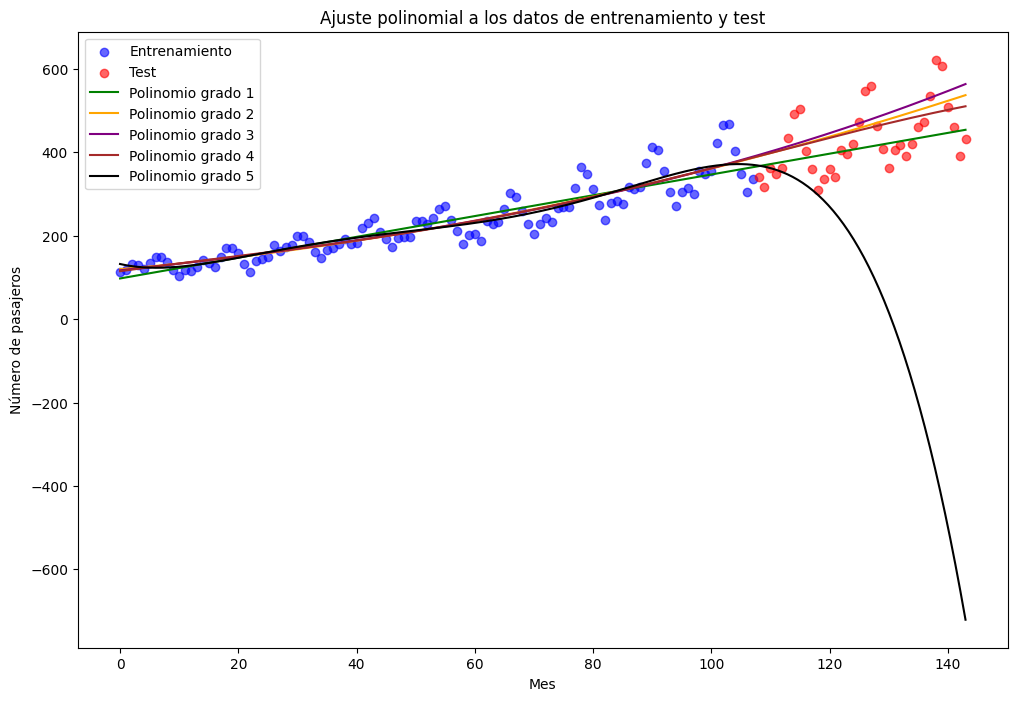

In [6]:
plt.figure(figsize=(12,8))

# Plot
plt.scatter(x_train, y_train, color="blue", label="Entrenamiento", alpha=0.6)
plt.scatter(x_test, y_test, color="red", label="Test", alpha=0.6)

# Grid
x_grid = np.linspace(min(x), max(x), 500)

# Colors for different degrees
colors = ["green", "orange", "purple", "brown", "black"]

for d, c in zip(degrees, colors):
    y_pred = np.polyval(models[d], x_grid)
    plt.plot(x_grid, y_pred, color=c, label=f"Polinomio grado {d}")

plt.xlabel("Mes")
plt.ylabel("Número de pasajeros")
plt.title("Ajuste polinomial a los datos de entrenamiento y test")
plt.legend()
plt.show()


In [ ]:
# (c)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def evaluar_modelo(coefs, x_train, y_train, x_test, y_test):
    # Predicciones
    y_pred_train = np.polyval(coefs, x_train)
    y_pred_test = np.polyval(coefs, x_test)
    
    # Métricas en test
    mse = mean_squared_error(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2  = r2_score(y_test, y_pred_test)
    msle = mean_squared_log_error(y_test, np.maximum(y_pred_test, 0))
    
    return mse, mae, r2, msle

In [8]:
resultados = {}

for d, coefs in models.items():
    print(f"Evaluando modelo grado {d}")
    resultados[d] = evaluar_modelo(coefs, x_train, y_train, x_test, y_test)

import pandas as pd
df_resultados = pd.DataFrame(resultados, index=["MSE","MAE","R2","MSLE"]).T
print(df_resultados)


Evaluando modelo grado 1
Evaluando modelo grado 2
Evaluando modelo grado 3
Evaluando modelo grado 4
Evaluando modelo grado 5
             MSE         MAE         R2       MSLE
1    4989.595774   53.301935   0.184481   0.023749
2    5526.306966   66.369291   0.096759   0.029067
3    6626.679869   72.674704  -0.083091   0.034335
4    5054.938501   62.649624   0.173801   0.026715
5  283619.431589  392.546292 -45.355879  14.288506


In [ ]:
# (d)
# Modelo 
def modelo(theta, x, fpol):
    theta1, theta2, theta3, theta4 = theta
    return fpol(x) + theta1 * np.sin(theta2 * x + theta3) * np.exp(theta4 * x)


# Log verosimilitud
from scipy.optimize import minimize

def objective(theta, x, y, fpol):
    y_pred = modelo(theta, x, fpol)
    residuals = y - y_pred
    return np.sum(residuals**2) 

In [10]:
# Optimizacion con BFGS
# fpol obtenido 
grado = 3
coefs = np.polyfit(x_train, y_train, grado)
fpol = np.poly1d(coefs)

# condición inicial
theta0 = [100, 0.5, 0, 0.01]

result = minimize(objective, theta0, args=(x_train, y_train, fpol), method="BFGS")
theta_hat = result.x
print("Parámetros estimados:", theta_hat)
print("theta 1:", theta_hat[0])
print("theta 2:", theta_hat[1])
print("theta 3:", theta_hat[2])
print("theta 4:", theta_hat[3])

Parámetros estimados: [ 3.17667493e+03  4.73451358e-03 -2.23321283e-03 -5.08524866e-01]
theta 1: 3176.674934510906
theta 2: 0.004734513576417868
theta 3: -0.00223321282517136
theta 4: -0.5085248662876302


In [11]:
# Metricas en test
y_pred_test = modelo(theta_hat, x_test, fpol)

mse  = mean_squared_error(y_test, y_pred_test)
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)
msle = mean_squared_log_error(y_test, np.maximum(y_pred_test,0))

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
print("MSLE:", msle)


MSE: 6626.679868646662
MAE: 72.67470356776025
R2: -0.08309070354119386
MSLE: 0.03433544118622514


   Init θ4          MSE        MAE        R2      MSLE
0    -1.00  6626.679869  72.674704 -0.083091  0.034335
1    -0.50  6626.679869  72.674704 -0.083091  0.034335
2    -0.10  6626.674942  72.674668 -0.083090  0.034335
3     0.00  6626.679869  72.674704 -0.083091  0.034335
4     0.01  6626.679869  72.674704 -0.083091  0.034335
5     0.10  6626.679869  72.674704 -0.083091  0.034335
6     0.50  6626.679869  72.674704 -0.083091  0.034335
7     1.00  6626.679869  72.674704 -0.083091  0.034335


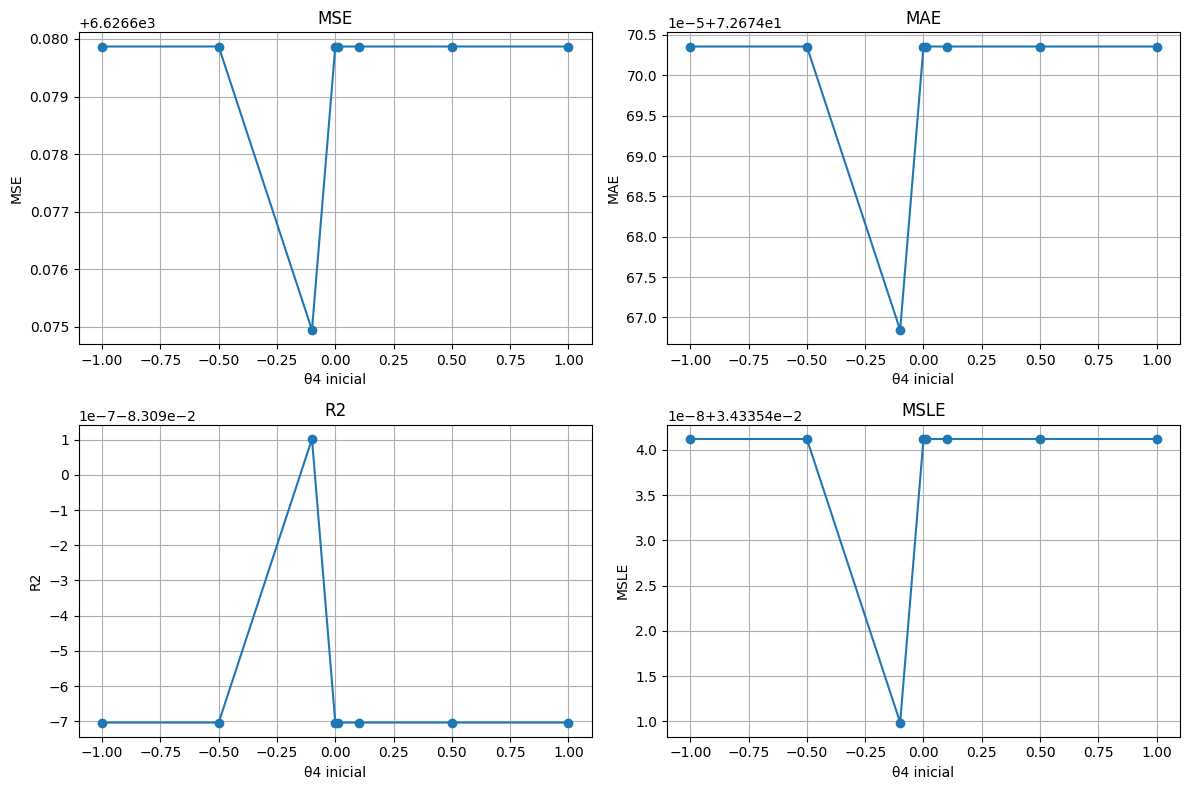

In [ ]:
theta4_inits = [-1.0, -0.5, -0.1, 0.0, 0.01, 0.1, 0.5, 1.0]

resultados = []

for t4 in theta4_inits:
    theta0 = [1000, 0.01, 0.0, t4]  
    res = minimize(objective, theta0, args=(x_train, y_train, fpol), method="BFGS")
    theta_hat = res.x
    y_pred_test = modelo(theta_hat, x_test, fpol)
    
    mse  = mean_squared_error(y_test, y_pred_test)
    mae  = mean_absolute_error(y_test, y_pred_test)
    r2   = r2_score(y_test, y_pred_test)
    msle = mean_squared_log_error(y_test, np.maximum(y_pred_test, 0))
    
    resultados.append([t4, mse, mae, r2, msle])

# DataFrame con los resultados
df_res = pd.DataFrame(resultados, columns=["Init θ4", "MSE", "MAE", "R2", "MSLE"])
print(df_res)

# Graficar métricas vs inicialización de θ4
fig, axs = plt.subplots(2, 2, figsize=(12,8))
metrics = ["MSE","MAE","R2","MSLE"]

for ax, m in zip(axs.flat, metrics):
    ax.plot(df_res["Init θ4"], df_res[m], "o-", label=m)
    ax.set_title(m)
    ax.set_xlabel("θ4 inicial")
    ax.set_ylabel(m)
    ax.grid(True)

plt.tight_layout()
plt.show()


In [74]:
# (e)
# Polinomio ajustado en parte anterior
grado = 3
coefs = np.polyfit(x_train, y_train, grado)   
fpol = np.poly1d(coefs)

# Valores de la parte anterior
theta1 = 18.054196274807264
theta2= 0.5178444827490423
theta3= -0.4433887249219437
theta4= -0.007850456991964475
def fpol_sin(x):
    return fpol(x) + theta1 * np.sin(theta2 * x + theta3) * np.exp(theta4 * x)


def modelo_doble(theta, x, fpol_sin):
    theta5, theta6, theta7, theta8 = theta
    return fpol_sin(x) + theta5 * np.sin(theta6 * x + theta7) * np.exp(theta8 * x)

# Minimizamos la suma de cuadrados de los residuos
def objective2(theta, x, y, fpol_sin):
    y_pred = modelo_doble(theta, x, fpol_sin)
    residuals = y - y_pred
    return np.sum(residuals**2)

In [75]:
# condición inicial 
theta0 = [0.01, 0.01, 0, 0.01]

result2 = minimize(objective2, theta0, args=(x_train, y_train, fpol_sin), method="BFGS")
theta_hat2 = result2.x
print("Parámetros estimados:", theta_hat2)
print("theta 5:", theta_hat2[0])
print("theta 6:", theta_hat2[1])    
print("theta 7:", theta_hat2[2])
print("theta 8:", theta_hat2[3])

Parámetros estimados: [ 6.67174102e+00  5.30560609e-01 -5.24252605e+01  2.20979389e-02]
theta 5: 6.671741021254414
theta 6: 0.5305606094903884
theta 7: -52.42526045499221
theta 8: 0.0220979388778823


In [76]:
y_pred_test2 = modelo_doble(theta_hat2, x_test, fpol_sin)

mse2  = mean_squared_error(y_test, y_pred_test2)
mae2  = mean_absolute_error(y_test, y_pred_test2)
r2_2  = r2_score(y_test, y_pred_test2)
msle2 = mean_squared_log_error(y_test, np.maximum(y_pred_test2,0))

print("MSE:", mse2)
print("MAE:", mae2)
print("R2:", r2_2)
print("MSLE:", msle2)

MSE: 4194.265006566138
MAE: 52.22655714652363
R2: 0.31447277869970824
MSLE: 0.018432767260977926


# Pregunta 3

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import random

# seed
random.seed(42)
np.random.seed(42)

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar dataset
data = pd.read_csv("golf_dataset.csv")

# Variables
features = ["Outlook", "Windy", "Temperature", "Humidity", "Crowdedness"]
target = "Play"

X = data[features]
y = data[target]

# Dividir en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Priors
priors = y_train.value_counts(normalize=True).to_dict()
print("Priors:", priors)

Priors: {0: 0.8152315720808871, 1: 0.18476842791911285}


In [23]:
# Tablas condicionales para categóricas
cond_probs_cat = {}
categorical = ["Outlook", "Windy"]

for col in categorical:
    cond_probs_cat[col] = {}
    for cls in y_train.unique():
        subset = X_train[y_train == cls][col]
        probs = subset.value_counts(normalize=True).to_dict()
        cond_probs_cat[col][cls] = probs

for col in categorical:
    rows = []
    for cls in cond_probs_cat[col]:
        for val, prob in cond_probs_cat[col][cls].items():
            rows.append({"Variable": col, "Clase": cls, "Valor": val, "P(x|Clase)": round(prob, 3)})
    df = pd.DataFrame(rows)
    print(f"\nProbabilidades condicionales para {col}:\n")
    print(df.to_string(index=False))


Probabilidades condicionales para Outlook:

Variable  Clase    Valor  P(x|Clase)
 Outlook      0    sunny       0.394
 Outlook      0 overcast       0.354
 Outlook      0    rainy       0.198
 Outlook      0     snow       0.053
 Outlook      1    sunny       0.551
 Outlook      1 overcast       0.315
 Outlook      1    rainy       0.090
 Outlook      1     snow       0.044

Probabilidades condicionales para Windy:

Variable  Clase  Valor  P(x|Clase)
   Windy      0      1       0.524
   Windy      0      0       0.476
   Windy      1      0       0.553
   Windy      1      1       0.447


In [25]:
# Parámetros para numéricas
# Asumimos Normal -> se estima media y desviación estándar para cada clase y cada variable
cond_params_num = {}
numerical = ["Temperature", "Humidity", "Crowdedness"]

for col in numerical:
    cond_params_num[col] = {}
    for cls in y_train.unique():
        values = X_train[y_train == cls][col]
        mu, sigma = values.mean(), values.std()
        cond_params_num[col][cls] = (mu, sigma)

rows = []
for col in cond_params_num:
    for cls, (mu, sigma) in cond_params_num[col].items():
        rows.append({
            "Variable": col,
            "Clase": cls,
            "Media (µ)": round(mu, 2),
            "Desv. Est. (σ)": round(sigma, 2)
        })

df_num = pd.DataFrame(rows)
print("\nParámetros numéricos (media y desviación estándar):\n")
print(df_num.to_string(index=False))


Parámetros numéricos (media y desviación estándar):

   Variable  Clase  Media (µ)  Desv. Est. (σ)
Temperature      0      13.46            8.11
Temperature      1      13.04            7.65
   Humidity      0      62.00           14.42
   Humidity      1      58.35           13.78
Crowdedness      0       0.61            0.15
Crowdedness      1       0.68            0.15


In [26]:
# Predicción
from math import sqrt, pi, exp

def gaussian_prob(x, mu, sigma):
    return (1/(sqrt(2*pi)*sigma)) * exp(-((x-mu)**2)/(2*sigma**2))

def predict_naive_bayes(x):
    posteriors = {}
    for cls in y_train.unique():
        # prior
        prob = priors[cls]
        
        # categóricas
        for col in categorical:
            val = x[col]
            prob *= cond_probs_cat[col][cls].get(val, 1e-6)  # smoothing
        
        # numéricas
        for col in numerical:
            mu, sigma = cond_params_num[col][cls]
            prob *= gaussian_prob(x[col], mu, sigma)
        
        posteriors[cls] = prob
    
    return max(posteriors, key=posteriors.get)

In [27]:
# (b) predicciones en train y test
# Predicciones en test
y_pred_test = X_test.apply(predict_naive_bayes, axis=1)

# Predicciones en train
y_pred_train = X_train.apply(predict_naive_bayes, axis=1)

print("Accuracy en train:", (y_pred_train == y_train).mean())
print("Accuracy en test:", (y_pred_test == y_test).mean())

Accuracy en train: 0.8140900195694716
Accuracy en test: 0.822570123939987


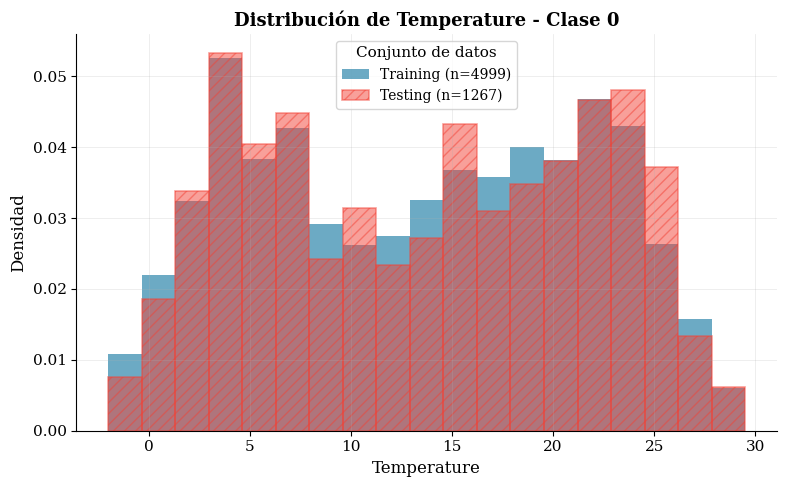

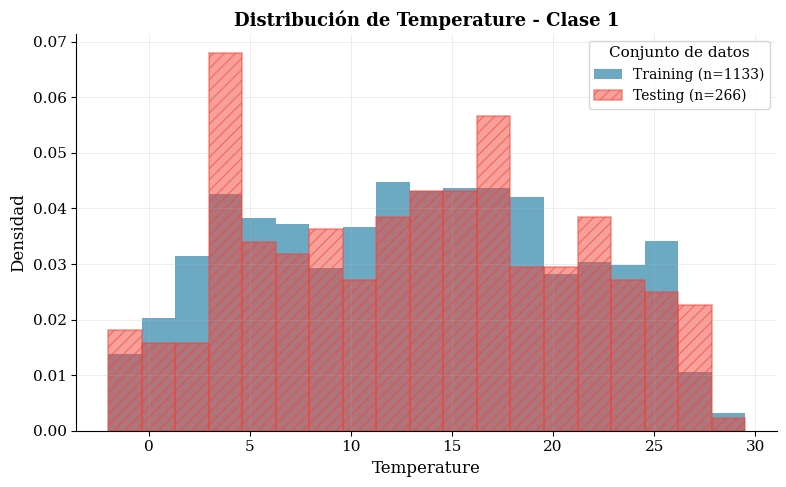

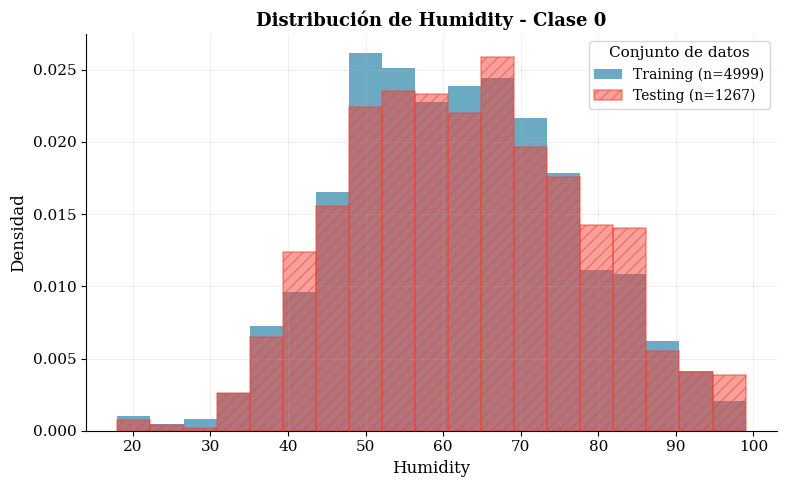

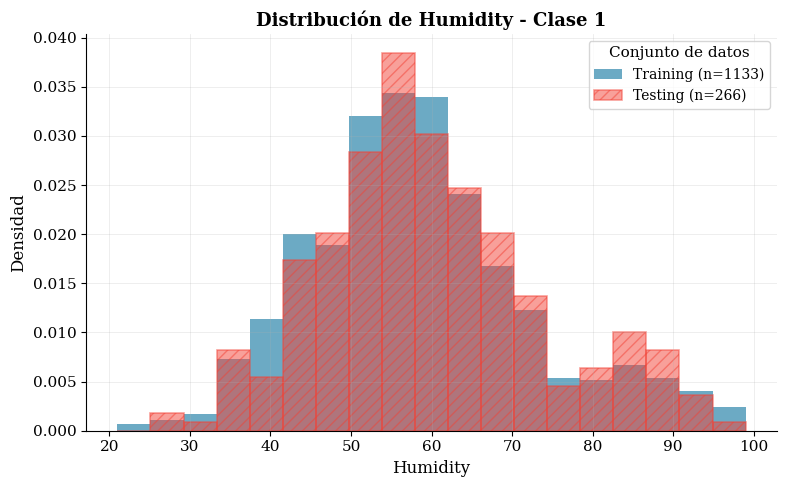

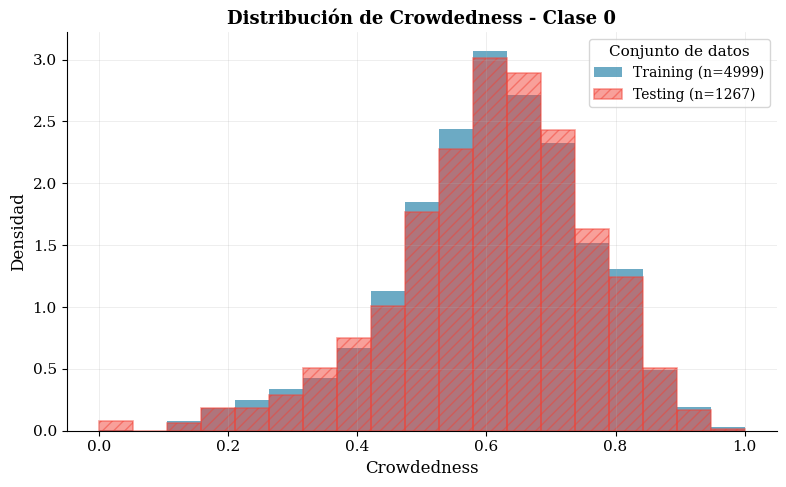

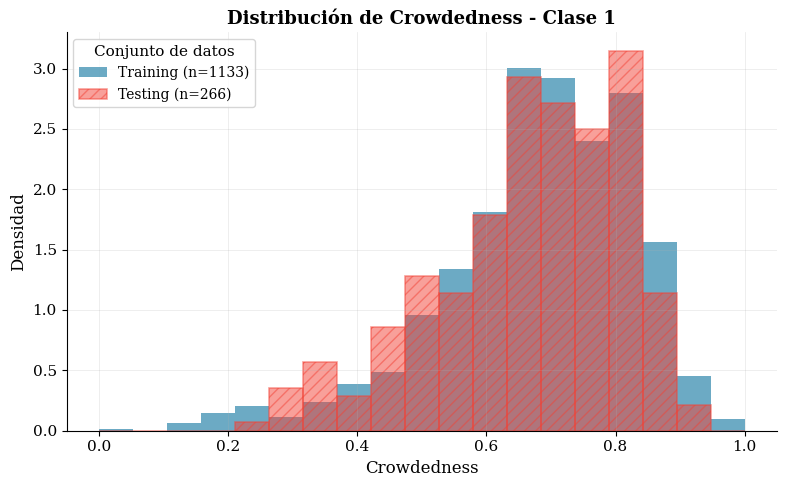

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_distributions(X_train, y_train, X_test, y_test, target_name, numerical_features):
    # Configuración
    plt.rcParams.update({
        'font.size': 11,
        'axes.labelsize': 12,
        'axes.titlesize': 13,
        'figure.dpi': 100,
        'font.family': 'serif'
    })

    # Datos
    train_df = X_train.copy()
    train_df[target_name] = y_train.values if hasattr(y_train, 'values') else y_train
    test_df = X_test.copy()
    test_df[target_name] = y_test.values if hasattr(y_test, 'values') else y_test

    colors = {'train': '#2E86AB', 'test': '#F24236'}

    for feature in numerical_features:
        for class_label in sorted(train_df[target_name].unique()):
            fig, ax = plt.subplots(figsize=(8, 5))

            # Datos por clase
            train_data = train_df[train_df[target_name] == class_label][feature].dropna()
            test_data = test_df[test_df[target_name] == class_label][feature].dropna()

            if len(train_data) == 0 and len(test_data) == 0:
                plt.close()
                continue

            # Bins comunes
            all_values = np.concatenate([train_data, test_data]) if len(train_data) > 0 and len(test_data) > 0 else (train_data if len(train_data) > 0 else test_data)
            bins = np.linspace(all_values.min(), all_values.max(), 20)

            # Graficar distribuciones
            if len(train_data) > 0:
                ax.hist(train_data, bins=bins, density=True, alpha=0.7, color=colors['train'],
                        label=f'Training (n={len(train_data)})')
            if len(test_data) > 0:
                ax.hist(test_data, bins=bins, density=True, alpha=0.5, facecolor=colors['test'],
                        edgecolor=colors['test'], hatch='///', linewidth=1.2,
                        label=f'Testing (n={len(test_data)})')

            # Formato 
            ax.set_title(f'Distribución de {feature} - Clase {class_label}', fontweight='bold')
            ax.set_xlabel(feature)
            ax.set_ylabel('Densidad')
            ax.legend(title='Conjunto de datos', frameon=True, shadow=False, fontsize=10)
            ax.grid(True, alpha=0.3, linewidth=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            plt.tight_layout()
            plt.show()

# Columnas numéricas
numerical_cols = ['Temperature', 'Humidity', 'Crowdedness']
plot_feature_distributions(X_train, y_train, X_test, y_test, 'target', numerical_cols)

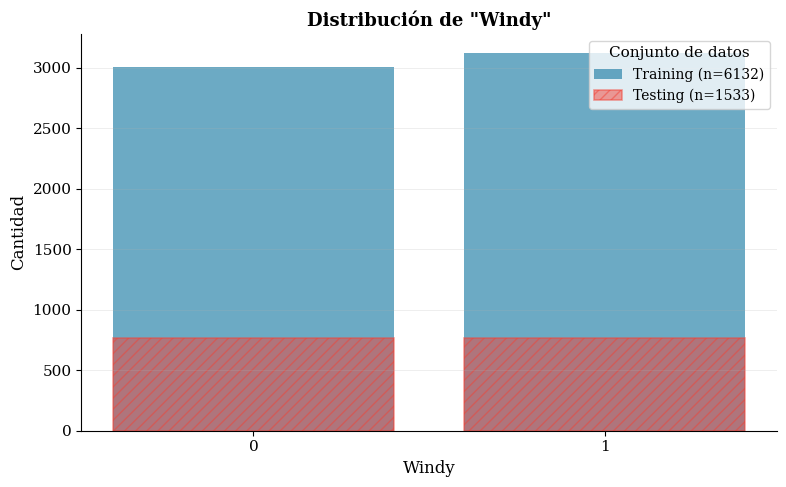

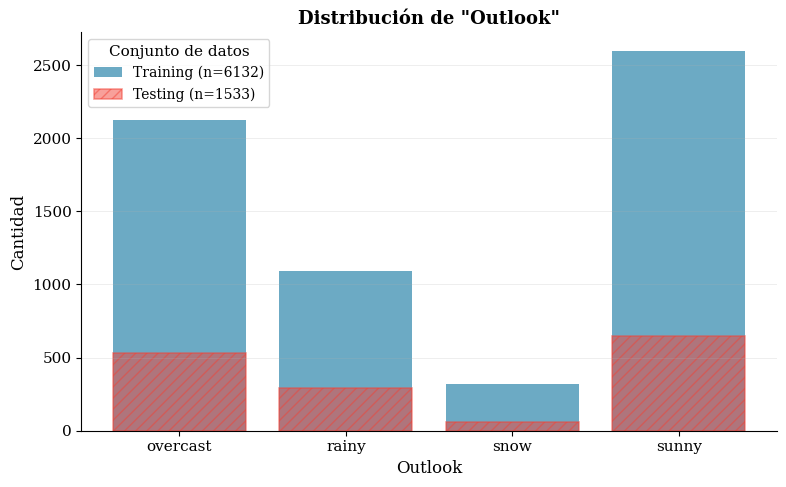

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_categorical_distribution(X_train, y_train, X_test, y_test, categorical_features):
    # Configuración
    plt.rcParams.update({
        'font.size': 11,
        'axes.labelsize': 12,
        'axes.titlesize': 13,
        'figure.dpi': 100,
        'font.family': 'serif'
    })

    # Preparar datos
    train_df = X_train.copy()
    train_df['target'] = y_train.values if hasattr(y_train, 'values') else y_train
    test_df = X_test.copy()
    test_df['target'] = y_test.values if hasattr(y_test, 'values') else y_test

    colors = {'train': '#2E86AB', 'test': '#F24236'}

    for feature in categorical_features:
        # Valores posibles
        if feature == 'Windy':
            categories = [0, 1]
        else:
            categories = sorted(train_df[feature].dropna().unique())

        # Contar ocurrencias y rellenar categorías faltantes
        counts_train = train_df[feature].value_counts().reindex(categories, fill_value=0)
        counts_test = test_df[feature].value_counts().reindex(categories, fill_value=0)

        # Crear gráfico combinado
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(counts_train.index, counts_train.values, color=colors['train'], alpha=0.7,
               label=f'Training (n={len(train_df)})')
        ax.bar(counts_test.index, counts_test.values, color=colors['test'], alpha=0.5,
               edgecolor=colors['test'], hatch='///', linewidth=1.2,
               label=f'Testing (n={len(test_df)})')

        # Formato
        ax.set_title(f'Distribución de "{feature}"', fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Cantidad')
        ax.set_xticks(categories)
        ax.legend(title='Conjunto de datos', frameon=True, shadow=False, fontsize=10)
        ax.grid(True, alpha=0.3, linewidth=0.5, axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()

# Variables categóricas
categorical_cols = ['Windy', 'Outlook']

plot_categorical_distribution(X_train, y_train, X_test, y_test, categorical_cols)


In [28]:
from sklearn.metrics import classification_report

# Reporte detallado por clase (train y test)
print("Reporte Train:")
print(classification_report(y_train, y_pred_train, target_names=["Clase 0", "Clase 1"]))

print("\nReporte Test:")
print(classification_report(y_test, y_pred_test, target_names=["Clase 0", "Clase 1"]))

Reporte Train:
              precision    recall  f1-score   support

     Clase 0       0.82      0.99      0.90      4999
     Clase 1       0.46      0.03      0.06      1133

    accuracy                           0.81      6132
   macro avg       0.64      0.51      0.48      6132
weighted avg       0.75      0.81      0.74      6132


Reporte Test:
              precision    recall  f1-score   support

     Clase 0       0.83      0.99      0.90      1267
     Clase 1       0.20      0.01      0.01       266

    accuracy                           0.82      1533
   macro avg       0.51      0.50      0.46      1533
weighted avg       0.72      0.82      0.75      1533



In [29]:
# matriz de confusion en test
from sklearn.metrics import confusion_matrix

cm_test = confusion_matrix(y_test, y_pred_test, labels=y_train.unique())
print("Matriz de confusión (Test):\n", cm_test)


Matriz de confusión (Test):
 [[1259    8]
 [ 264    2]]


In [30]:
# matriz de confusion en train
cm_train = confusion_matrix(y_train, y_pred_train, labels=y_train.unique())
print("Matriz de confusión (Train):\n", cm_train)

Matriz de confusión (Train):
 [[4955   44]
 [1096   37]]


In [32]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def calcular_metricas_por_clase(y_true, y_pred):
    clases = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=clases)
    resultados = []

    for i, c in enumerate(clases):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        accuracy  = (TP + TN) / cm.sum() if cm.sum() > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        fnr = FN / (FN + TP) if (FN + TP) > 0 else 0

        resultados.append({
            "Clase": c,
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall (TPR)": round(recall, 3),
            "Specificity (TNR)": round(specificity, 3),
            "F1-Score": round(f1, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3)
        })

    return pd.DataFrame(resultados)

# Ejemplo con tus datos
df_train = calcular_metricas_por_clase(y_train, y_pred_train)
df_test  = calcular_metricas_por_clase(y_test, y_pred_test)

print("\nMétricas por clase - Train:")
print(df_train)

print("\nMétricas por clase - Test:")
print(df_test)


Métricas por clase - Train:
   Clase  Accuracy  Precision  Recall (TPR)  Specificity (TNR)  F1-Score  \
0      0     0.814      0.819         0.991              0.033     0.897   
1      1     0.814      0.457         0.033              0.991     0.061   

     FPR    FNR  
0  0.967  0.009  
1  0.009  0.967  

Métricas por clase - Test:
   Clase  Accuracy  Precision  Recall (TPR)  Specificity (TNR)  F1-Score  \
0      0     0.823      0.827         0.994              0.008     0.903   
1      1     0.823      0.200         0.008              0.994     0.014   

     FPR    FNR  
0  0.992  0.006  
1  0.006  0.992  


In [ ]:
# (c)
# preprocesamiento
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Categóricas y numéricas
categorical = ["Outlook", "Windy"]
numerical = ["Temperature", "Humidity", "Crowdedness"]

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical), 
        ("num", "passthrough", numerical)
    ]
)

# Modelo de Regresión Logística
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Entrenamiento
log_reg.fit(X_train, y_train)

# Predicciones
y_pred_train_lr = log_reg.predict(X_train)
y_pred_test_lr  = log_reg.predict(X_test)

In [51]:
df_train_lr = calcular_metricas_por_clase(y_train, y_pred_train_lr)
df_test_lr  = calcular_metricas_por_clase(y_test, y_pred_test_lr)

print("\nMétricas por clase - Train:")
print(df_train_lr)

print("\nMétricas por clase - Test:")
print(df_test_lr)


Métricas por clase - Train:
   Clase  Accuracy  Precision  Recall (TPR)  Specificity (TNR)  F1-Score  FPR  \
0      0     0.815      0.815           1.0                0.0     0.898  1.0   
1      1     0.815      0.000           0.0                1.0     0.000  0.0   

   FNR  
0  0.0  
1  1.0  

Métricas por clase - Test:
   Clase  Accuracy  Precision  Recall (TPR)  Specificity (TNR)  F1-Score  FPR  \
0      0     0.826      0.826           1.0                0.0     0.905  1.0   
1      1     0.826      0.000           0.0                1.0     0.000  0.0   

   FNR  
0  0.0  
1  1.0  


In [17]:
# coeficientes
# Nombres de las variables transformadas
feature_names = log_reg.named_steps["preprocessor"].get_feature_names_out()

# Coeficientes
coefs = log_reg.named_steps["classifier"].coef_[0]
coef_table = pd.DataFrame({"Variable": feature_names, "Coeficiente": coefs})
print("\nCoeficientes de la regresión logística:\n")
print(coef_table.to_string(index=False))



Coeficientes de la regresión logística:

          Variable  Coeficiente
cat__Outlook_rainy    -0.336031
 cat__Outlook_snow     0.477981
cat__Outlook_sunny     0.240162
      cat__Windy_1    -0.173554
  num__Temperature     0.003243
     num__Humidity    -0.008215
  num__Crowdedness     2.848908
